# 💳 Credit Card Fraud Detection using Machine Learning

## 📌 Project Overview
Credit card fraud detection is a real-world machine learning classification problem where the objective is to identify fraudulent transactions while minimizing false alarms. Since fraudulent transactions are rare compared to legitimate ones, this is an imbalanced classification problem.

## 🎯 Objectives
- Understand and explore the dataset.
- Perform data preprocessing and cleaning.
- Analyze class imbalance.
- Train and evaluate machine learning models.
- Detect fraudulent transactions accurately.
- Interpret model performance using appropriate metrics.

## 🧰 Technologies Used
- Python
- Pandas & NumPy
- Matplotlib & Seaborn
- Scikit-learn
- Jupyter Notebook

## 📂 Machine Learning Workflow
1. Import libraries
2. Load dataset
3. Explore and understand data
4. Perform preprocessing
5. Analyze fraud distribution
6. Split data into training and testing sets
7. Train the ML model
8. Make predictions
9. Evaluate performance
10. Draw conclusions


## 📖 Explanation
This cell imports all required libraries for data manipulation, visualization, preprocessing, model training, and evaluation.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import gridspec
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef, confusion_matrix


## 📖 Explanation
This cell loads the credit card transaction dataset into a Pandas DataFrame.

In [2]:
data = pd.read_csv("creditcard.csv")
print(data.head())

   Time        V1        V2        V3        V4        V5        V6        V7  \
0     0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1     0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2     1 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3     1 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4     2 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

## 📖 Explanation
This step explores the dataset to understand the number of rows, columns, data types, and summary statistics.

In [3]:
print(data.describe())

               Time           V1           V2           V3           V4  \
count   7973.000000  7973.000000  7973.000000  7973.000000  7973.000000   
mean    4257.151261    -0.299740     0.295226     0.899355     0.215736   
std     3198.964299     1.498341     1.283914     1.090297     1.447057   
min        0.000000   -23.066842   -25.640527   -12.389545    -4.657545   
25%     1531.000000    -1.046362    -0.237359     0.372435    -0.687521   
50%     3635.000000    -0.416341     0.335446     0.948695     0.223379   
75%     6662.000000     1.122758     0.950582     1.597949     1.131542   
max    10981.000000     1.685314     8.261750     4.101716     7.380245   

                V5           V6           V7           V8           V9  ...  \
count  7973.000000  7973.000000  7973.000000  7973.000000  7973.000000  ...   
mean     -0.025285     0.157286    -0.026445    -0.070525     0.655244  ...   
std       1.167218     1.325015     1.063709     1.332568     1.156618  ...   
min     

## 📖 Explanation
This cell performs the next step in the end-to-end machine learning pipeline.

In [4]:
fraud = data[data['Class'] == 1]
valid = data[data['Class'] == 0]
outlierFraction = len(fraud)/float(len(valid))
print(outlierFraction)
print('Fraud Cases: {}'.format(len(data[data['Class'] == 1])))
print('Valid Transactions: {}'.format(len(data[data['Class'] == 0])))

0.0031458411979363283
Fraud Cases: 25
Valid Transactions: 7947


## 📖 Explanation
This step explores the dataset to understand the number of rows, columns, data types, and summary statistics.

In [5]:
print("Amount details of the fraudulent transaction")
fraud.Amount.describe()

Amount details of the fraudulent transaction


,Amount
count,25.000000
mean,106.308400
std,372.676883
min,0.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,1809.680000


## 📖 Explanation
This step explores the dataset to understand the number of rows, columns, data types, and summary statistics.

In [6]:
print("details of valid transaction")
valid.Amount.describe()

details of valid transaction


,Amount
count,7947.000000
mean,65.284891
std,194.126547
min,0.000000
25%,4.795000
50%,15.950000
75%,54.990000
max,7712.430000


## 📖 Explanation
This visualization helps understand data distribution, feature relationships, and fraud patterns.

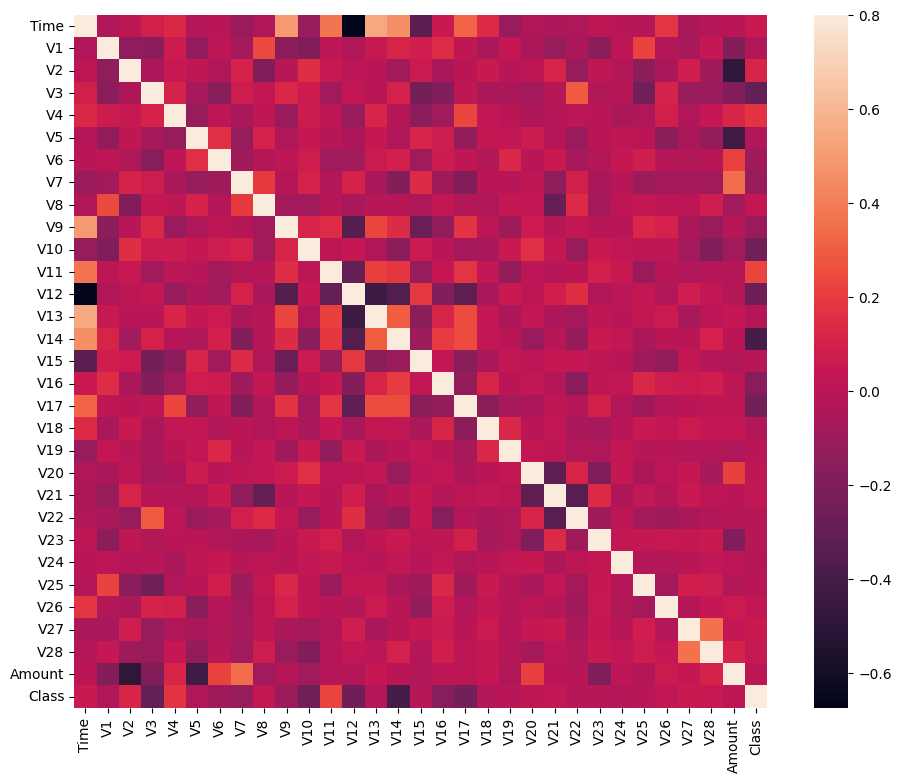

In [7]:
corrmat = data.corr()
fig = plt.figure(figsize = (12, 9))
sns.heatmap(corrmat, vmax = .8, square = True)
plt.show()

## 📖 Explanation
This cell imports all required libraries for data manipulation, visualization, preprocessing, model training, and evaluation.

In [8]:
X = data.drop(['Class'], axis = 1)
Y = data["Class"]
print(X.shape)
print(Y.shape)

xData = X.values
yData = Y.values

from sklearn.model_selection import train_test_split
xTrain, xTest, yTrain, yTest = train_test_split(
        xData, yData, test_size = 0.2, random_state = 42)

(7973, 30)
(7973,)


## 📖 Explanation
This cell performs the next step in the end-to-end machine learning pipeline.

In [9]:
non_nan_mask = ~np.isnan(yTrain)

## 📖 Explanation
This cell performs the next step in the end-to-end machine learning pipeline.

In [10]:

xTrain_cleaned = xTrain[non_nan_mask]
yTrain_cleaned = yTrain[non_nan_mask]


## 📖 Explanation
This cell performs the next step in the end-to-end machine learning pipeline.

In [11]:

rfc = RandomForestClassifier()

## 📖 Explanation
This cell performs the next step in the end-to-end machine learning pipeline.

In [12]:
xTrain_cleaned

array([[ 1.96400000e+03, -1.61806245e+00, -2.83935800e-01, ...,
        -1.85213647e-01,  2.82433054e-01,  4.99900000e+01],
       [ 1.17900000e+03,  6.57389339e-01, -6.43789396e-01, ...,
         1.14239002e-02,  7.49778628e-02,  2.51350000e+02],
       [ 1.88000000e+02,  1.16843339e+00,  3.19977589e-01, ...,
         2.18927266e-02,  1.93366400e-02,  8.09000000e+00],
       ...,
       [ 6.54000000e+02, -8.33568321e-01,  6.06174188e-01, ...,
         1.64383985e-01,  2.74361005e-01,  9.90000000e+00],
       [ 1.05180000e+04, -2.26083429e+00, -7.58476478e-01, ...,
         2.49838190e-01, -5.77953345e-03,  9.50000000e-01],
       [ 9.67300000e+03, -1.61547335e+00,  1.50325911e+00, ...,
        -1.11060384e+00,  1.15793236e-01,  2.99900000e+01]])

## 📖 Explanation
This cell performs the next step in the end-to-end machine learning pipeline.

In [13]:
yTrain_cleaned

array([0., 0., 0., ..., 0., 0., 0.])

## 📖 Explanation
This cell imports all required libraries for data manipulation, visualization, preprocessing, model training, and evaluation.

In [31]:
import pandas as pd

results = pd.DataFrame({
    'Actual': yTest,
    'Predicted': yPred
})

results = results.dropna()

yTest = results['Actual']
yPred = results['Predicted']

## 📖 Explanation
This cell performs the next step in the end-to-end machine learning pipeline.

In [14]:

non_nan_mask

array([ True,  True,  True, ...,  True,  True,  True])

## 📖 Explanation
This cell imports all required libraries for data manipulation, visualization, preprocessing, model training, and evaluation.

In [24]:
from sklearn.ensemble import RandomForestClassifier
import numpy as np
non_nan_mask = ~np.isnan(yTrain)

xTrain_cleaned = xTrain[non_nan_mask]
yTrain_cleaned = yTrain[non_nan_mask]

rfc = RandomForestClassifier()
rfc.fit(xTrain_cleaned, yTrain_cleaned)
yPred = rfc.predict(xTest)

## 📖 Explanation
This cell imports all required libraries for data manipulation, visualization, preprocessing, model training, and evaluation.

Model Evaluation Metrics:
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1-Score: 1.0000
Matthews Correlation Coefficient: 1.0000


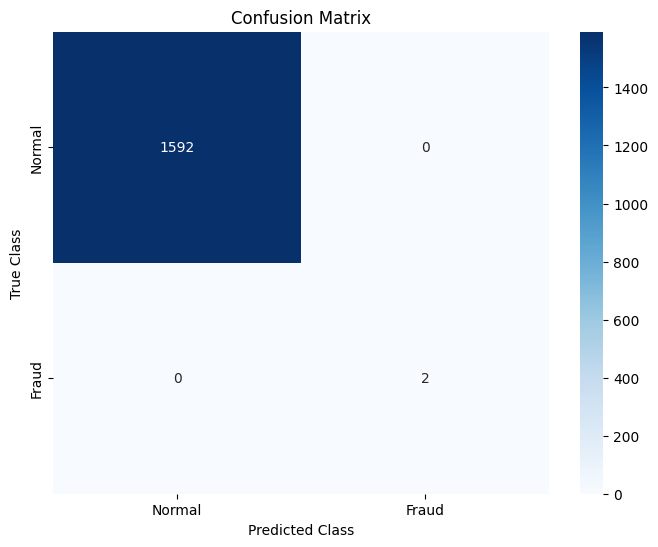

In [32]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef, confusion_matrix
accuracy = accuracy_score(yTest, yPred)
precision = precision_score(yTest, yPred)
recall = recall_score(yTest, yPred)
f1 = f1_score(yTest, yPred)
mcc = matthews_corrcoef(yTest, yPred)

print("Model Evaluation Metrics:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"Matthews Correlation Coefficient: {mcc:.4f}")

conf_matrix = confusion_matrix(yTest, yPred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Normal', 'Fraud'], yticklabels=['Normal', 'Fraud'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.show()

## 📖 Explanation
This cell performs the next step in the end-to-end machine learning pipeline.

# ✅ Conclusion

This project demonstrates an end-to-end machine learning solution for detecting fraudulent credit card transactions. The notebook covers data understanding, preprocessing, exploratory analysis, model development, prediction, and evaluation. It highlights the challenges of imbalanced datasets and emphasizes the importance of evaluation metrics such as Precision, Recall, F1-score, and the Confusion Matrix when building fraud detection systems.

## 🚀 Key Skills Demonstrated
- Data Cleaning
- Exploratory Data Analysis (EDA)
- Feature Engineering
- Machine Learning Classification
- Model Evaluation
- Fraud Detection
- Python & Scikit-learn
